In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display charts
%matplotlib inline

In [4]:
df = pd.read_csv("dataset/Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(
    "dataset/Sample - Superstore.csv",
    encoding='latin1'
)

# Show first rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
import os

folders = ["charts", "sql_queries", "dashboard", "dataset"]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


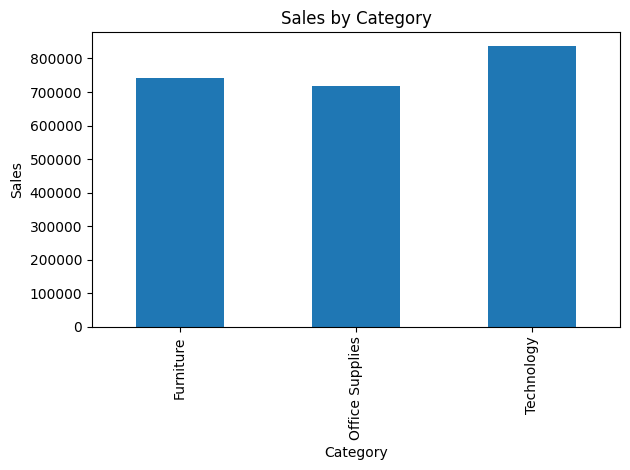

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataset/Sample - Superstore.csv", encoding='latin1')

category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()

plt.savefig("charts/sales_by_category.png")
plt.show()

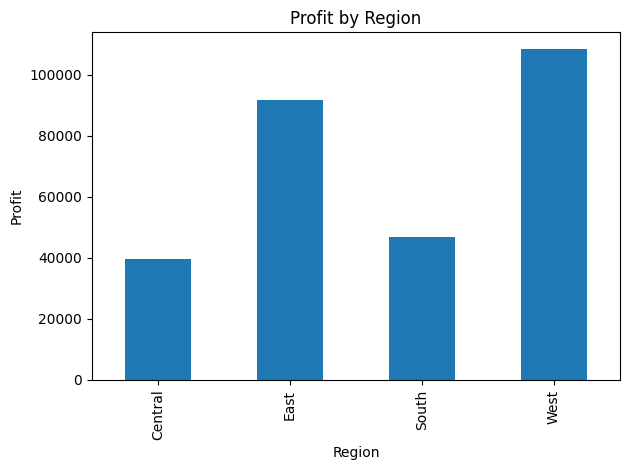

In [8]:
region_profit = df.groupby("Region")["Profit"].sum()

region_profit.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.tight_layout()

plt.savefig("charts/profit_by_region.png")
plt.show()

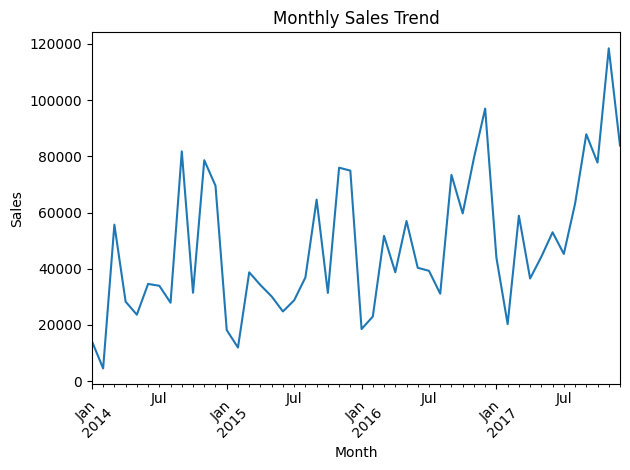

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("charts/monthly_sales_trend.png")
plt.show()

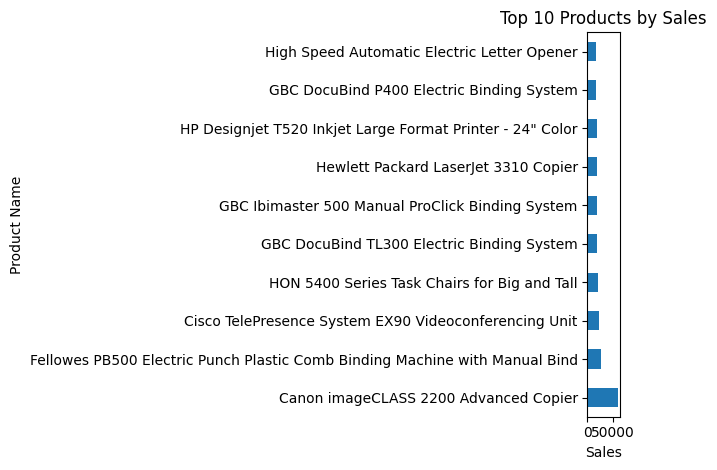

In [10]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.tight_layout()

plt.savefig("charts/top_10_products.png")
plt.show()

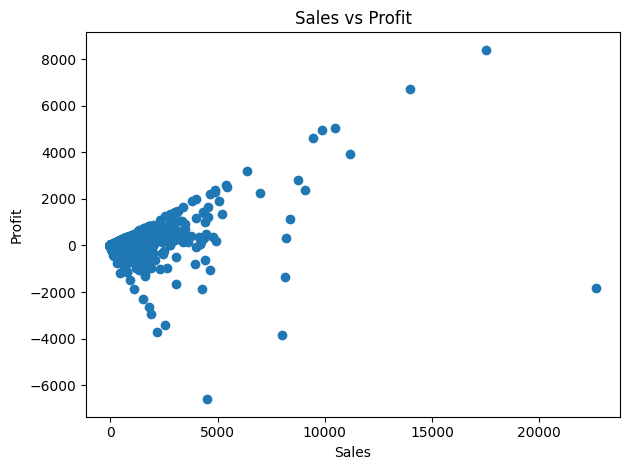

In [11]:
plt.scatter(df["Sales"], df["Profit"])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()

plt.savefig("charts/sales_vs_profit_scatter.png")
plt.show()

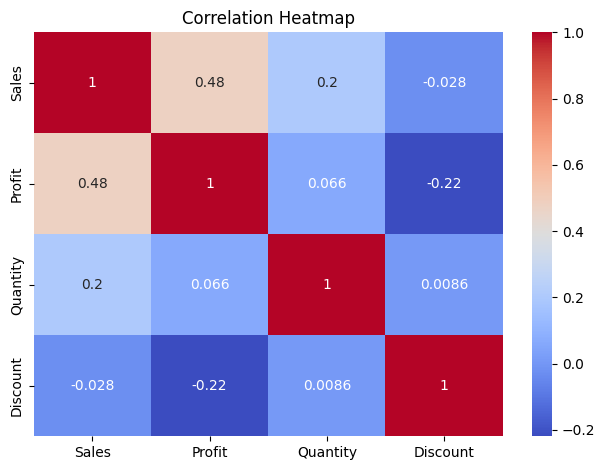

In [12]:
import seaborn as sns

correlation = df[["Sales", "Profit", "Quantity", "Discount"]].corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("charts/correlation_heatmap.png")
plt.show()

In [16]:
import sqlite3
import pandas as pd

# Load dataset
df = pd.read_csv("dataset/Sample - Superstore.csv", encoding='latin1')

# Create database connection
conn = sqlite3.connect("superstore.db")

# Store dataframe as SQL table
df.to_sql("superstore", conn, if_exists="replace", index=False)

# SQL query inside triple quotes
query = """
SELECT 
    "Product Name",
    SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 10;
"""

# Execute query
result = pd.read_sql(query, conn)

# Display result
print(result)

                                        Product Name  Total_Sales
0              Canon imageCLASS 2200 Advanced Copier    61599.824
1  Fellowes PB500 Electric Punch Plastic Comb Bin...    27453.384
2  Cisco TelePresence System EX90 Videoconferenci...    22638.480
3       HON 5400 Series Task Chairs for Big and Tall    21870.576
4         GBC DocuBind TL300 Electric Binding System    19823.479
5   GBC Ibimaster 500 Manual ProClick Binding System    19024.500
6               Hewlett Packard LaserJet 3310 Copier    18839.686
7  HP Designjet T520 Inkjet Large Format Printer ...    18374.895
8          GBC DocuBind P400 Electric Binding System    17965.068
9        High Speed Automatic Electric Letter Opener    17030.312


In [17]:
import sqlite3
import pandas as pd

# Load dataset
df = pd.read_csv("dataset/Sample - Superstore.csv", encoding='latin1')

# Create database connection
conn = sqlite3.connect("superstore.db")

# Store dataframe as SQL table
df.to_sql("superstore", conn, if_exists="replace", index=False)

# SQL query inside triple quotes
query = """
SELECT 
    Region,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY Region;
"""

result = pd.read_sql(query, conn)

print(result)

# Execute query
result = pd.read_sql(query, conn)

# Display result
print(result)

    Region  Total_Sales  Total_Profit
0  Central  501239.8908    39706.3625
1     East  678781.2400    91522.7800
2    South  391721.9050    46749.4303
3     West  725457.8245   108418.4489
    Region  Total_Sales  Total_Profit
0  Central  501239.8908    39706.3625
1     East  678781.2400    91522.7800
2    South  391721.9050    46749.4303
3     West  725457.8245   108418.4489


In [18]:
import sqlite3
import pandas as pd

# Load dataset
df = pd.read_csv("dataset/Sample - Superstore.csv", encoding='latin1')

# Create database connection
conn = sqlite3.connect("superstore.db")

# Store dataframe as SQL table
df.to_sql("superstore", conn, if_exists="replace", index=False)

# SQL query inside triple quotes
query = """
SELECT 
    strftime('%Y-%m', "Order Date") AS Month,
    SUM(Sales) AS Monthly_Sales
FROM superstore
GROUP BY Month
ORDER BY Month;
"""

result = pd.read_sql(query, conn)

print(result)
result = pd.read_sql(query, conn)

print(result)

# Execute query
result = pd.read_sql(query, conn)

# Display result
print(result)

  Month  Monthly_Sales
0  None   2.297201e+06
  Month  Monthly_Sales
0  None   2.297201e+06
  Month  Monthly_Sales
0  None   2.297201e+06


In [19]:
import sqlite3
import pandas as pd

# Load dataset
df = pd.read_csv("dataset/Sample - Superstore.csv", encoding='latin1')

# Create database connection
conn = sqlite3.connect("superstore.db")

# Store dataframe as SQL table
df.to_sql("superstore", conn, if_exists="replace", index=False)

# SQL query inside triple quotes
query = """
SELECT 
    Category,
    SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY Category
ORDER BY Total_Profit DESC;
"""

result = pd.read_sql(query, conn)

print(result)

result = pd.read_sql(query, conn)

print(result)
result = pd.read_sql(query, conn)

print(result)

# Execute query
result = pd.read_sql(query, conn)

# Display result
print(result)

          Category  Total_Profit
0       Technology   145454.9481
1  Office Supplies   122490.8008
2        Furniture    18451.2728
          Category  Total_Profit
0       Technology   145454.9481
1  Office Supplies   122490.8008
2        Furniture    18451.2728
          Category  Total_Profit
0       Technology   145454.9481
1  Office Supplies   122490.8008
2        Furniture    18451.2728
          Category  Total_Profit
0       Technology   145454.9481
1  Office Supplies   122490.8008
2        Furniture    18451.2728


In [20]:
import sqlite3
import pandas as pd

# Load dataset
df = pd.read_csv("dataset/Sample - Superstore.csv", encoding='latin1')

# Create database connection
conn = sqlite3.connect("superstore.db")

# Store dataframe as SQL table
df.to_sql("superstore", conn, if_exists="replace", index=False)

# SQL query inside triple quotes
query = """
SELECT 
    Segment,
    COUNT(DISTINCT "Customer ID") AS Total_Customers,
    SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Segment;
"""

result = pd.read_sql(query, conn)

print(result)

result = pd.read_sql(query, conn)

print(result)

result = pd.read_sql(query, conn)

print(result)
result = pd.read_sql(query, conn)

print(result)

# Execute query
result = pd.read_sql(query, conn)

# Display result
print(result)

       Segment  Total_Customers   Total_Sales
0     Consumer              409  1.161401e+06
1    Corporate              236  7.061464e+05
2  Home Office              148  4.296531e+05
       Segment  Total_Customers   Total_Sales
0     Consumer              409  1.161401e+06
1    Corporate              236  7.061464e+05
2  Home Office              148  4.296531e+05
       Segment  Total_Customers   Total_Sales
0     Consumer              409  1.161401e+06
1    Corporate              236  7.061464e+05
2  Home Office              148  4.296531e+05
       Segment  Total_Customers   Total_Sales
0     Consumer              409  1.161401e+06
1    Corporate              236  7.061464e+05
2  Home Office              148  4.296531e+05
       Segment  Total_Customers   Total_Sales
0     Consumer              409  1.161401e+06
1    Corporate              236  7.061464e+05
2  Home Office              148  4.296531e+05


In [2]:
import os

# ensure folder exists
os.makedirs("sql_queries", exist_ok=True)

query = """
SELECT 
    Segment,
    COUNT(DISTINCT "Customer ID") AS Total_Customers,
    SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Segment;
"""

# save SQL file
with open("sql_queries/segment_analysis.sql", "w") as f:
    f.write(query)

print("SQL file saved successfully!")

SQL file saved successfully!


In [3]:
import os

# ensure folder exists
os.makedirs("sql_queries", exist_ok=True)

query = """
SELECT 
    Segment,
    COUNT(DISTINCT "Customer ID") AS Total_Customers,
    SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Segment;
"""

# save SQL file
with open("sql_queries/segment_analysis.sql", "w") as f:
    f.write(query)

print("SQL file saved successfully!")

SQL file saved successfully!


In [5]:
import pandas as pd
import os

query = """
SELECT 
    Segment,
    COUNT(DISTINCT "Customer ID") AS Total_Customers,
    SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Segment;
"""

result = pd.read_sql(query, conn)

print(result)

       Segment  Total_Customers   Total_Sales
0     Consumer              409  1.161401e+06
1    Corporate              236  7.061464e+05
2  Home Office              148  4.296531e+05


In [9]:
os.makedirs("dashboard", exist_ok=True)

# Convert table to HTML with styling class
table_html = result.to_html(index=False, classes="styled-table")

# Add colorful CSS + HTML wrapper
html = f"""
<html>
<head>
    <style>
        body {{
            font-family: Arial;
            background: linear-gradient(to right, #ff9966, #ff5e62);
            padding: 20px;
        }}

        h1 {{
            text-align: center;
            color: white;
        }}

        .styled-table {{
            margin: auto;
            border-collapse: collapse;
            font-size: 18px;
            min-width: 60%;
            background: white;
            border-radius: 10px;
            overflow: hidden;
            box-shadow: 0px 0px 20px rgba(0,0,0,0.3);
        }}

        .styled-table th {{
            background-color: #4CAF50;
            color: white;
            padding: 12px;
        }}

        .styled-table td {{
            padding: 12px;
            border-bottom: 1px solid #ddd;
        }}

        .styled-table tr:hover {{
            background-color: #f1f1f1;
        }}
    </style>
</head>

<body>
    <h1>📊 Superstore Dashboard</h1>
    {table_html}
</body>
</html>
"""

with open("dashboard/dashboard.html", "w", encoding="utf-8") as f:
    f.write(html)

print("🎉 Dashboard saved successfully!")

🎉 Dashboard saved successfully!


In [7]:
import os
import pandas as pd

# 1. Load dataset (important: encoding fix)
df = pd.read_csv("dataset/Sample - Superstore.csv", encoding="ISO-8859-1")

# 2. Create analysis result (example: Category vs Sales)
result = df.groupby("Category")["Sales"].sum().reset_index()

# 3. Create dashboard folder
os.makedirs("dashboard", exist_ok=True)

# 4. Convert table to HTML
table_html = result.to_html(index=False, classes="styled-table")

# 5. Create colorful HTML dashboard
html = f"""
<html>
<head>
    <title>Superstore Dashboard</title>

    <style>
        body {{
            font-family: Arial;
            background: linear-gradient(to right, #ff9966, #ff5e62);
            padding: 20px;
        }}

        h1 {{
            text-align: center;
            color: white;
            margin-bottom: 20px;
        }}

        .styled-table {{
            border-collapse: collapse;
            margin: auto;
            font-size: 18px;
            min-width: 60%;
            background-color: white;
            border-radius: 10px;
            overflow: hidden;
            box-shadow: 0px 0px 20px rgba(0,0,0,0.3);
        }}

        .styled-table th {{
            background-color: #4CAF50;
            color: white;
            padding: 12px;
        }}

        .styled-table td {{
            padding: 12px;
            border-bottom: 1px solid #ddd;
        }}

        .styled-table tr:hover {{
            background-color: #f1f1f1;
        }}
    </style>
</head>

<body>
    <h1>📊 Sample Superstore Dashboard</h1>
    {table_html}
</body>
</html>
"""

# 6. Save dashboard
with open("dashboard/dashboard.html", "w", encoding="utf-8") as f:
    f.write(html)

print("✅ Dashboard created successfully!")

✅ Dashboard created successfully!
